In [14]:
import numpy as np
import matplotlib.pyplot as plt 
from testCases import *
from planar_utils import *
np.random.seed(1)

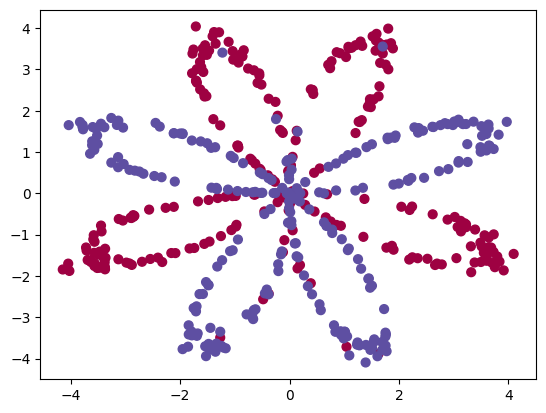

In [15]:
X,Y=load_planar_dataset(m=500)
plt.scatter(X[0,:],X[1,:],c=Y.ravel(),s=40,cmap=plt.cm.Spectral)
plt.show()

In [16]:
print(X.shape)
print(Y.shape)
# print(X[:,:5])
# print(Y[:,:5])
idx=np.random.choice(X.shape[1],size=5,replace=False)
print("random index:",idx)
for i in idx:
    print(f"index: {i:4d}: X=[{X[0,i]:7.4f},{X[1,i]:7.4f}],Y={int(Y[0,i])}")

(2, 500)
(1, 500)
random index: [456 216 196  83 258]
index:  456: X=[-0.4927, 0.4642],Y=1
index:  216: X=[-1.0390, 3.4431],Y=0
index:  196: X=[-1.7804, 2.9073],Y=0
index:   83: X=[-3.5643,-1.6872],Y=0
index:  258: X=[-0.0072, 0.3438],Y=1


In [17]:
def sigmoid(Z):
    return 1/(1+np.exp(-Z))
    

In [39]:
def init_params(n_h):
    w1=np.random.randn(n_h,2)*0.01
    b1=np.zeros((n_h,1))
    w2=np.random.randn(1,n_h)*0.01
    b2=0
    params={"w1":w1,"w2":w2,"b1":b1,"b2":b2}
    return params
    


In [56]:
def predict(X,params):
    w1=params["w1"]
    w2=params["w2"]
    b1=params["b1"]
    b2=params["b2"]
    m=X.shape[1]
    z1=np.dot(w1,X)+b1
    a1=np.tanh(z1)
    z2=np.dot(w2,a1)+b2
    a2=sigmoid(z2)

    Y=(a2>0.5).astype(int)
    return Y
def train(X,Y,params,lr):
    w1=params["w1"]
    w2=params["w2"]
    b1=params["b1"]
    b2=params["b2"]

    for i in range(30000):
        m=X.shape[1]
        z1=np.dot(w1,X)+b1
        a1=np.tanh(z1)
        z2=np.dot(w2,a1)+b2
        a2=sigmoid(z2)
        a2 = np.clip(a2, 1e-10, 1 - 1e-10)

        cost=(-1/m)*np.sum(Y*np.log(a2)+(1-Y)*np.log(1-a2))
        if i%500==0:
            print(f"iterations:{i},cost:",cost)

        da2=1
        dz2=a2-Y
        dw2=np.dot(dz2,a1.T)/m
        db2=1/m*np.sum(dz2)
        da1=np.dot(w2.T,dz2)
        dz1=da1*(1-np.power(a1,2))
        dw1=np.dot(dz1,X.T)/m
        db1=np.sum(dz1,axis=1,keepdims=True)/m

        w2=w2-lr*dw2
        w1=w1-lr*dw1
        b2=b2-lr*db2
        b1=b1-lr*db1

    params={"w1":w1,"w2":w2,"b1":b1,"b2":b2}
    a2=predict(X,params)
    Y_pre=(a2>0.5).astype(int)
    accuracy=np.mean(Y==np.ravel(Y_pre))
    return params,accuracy


In [57]:
params=init_params(n_h=20)
params,acc=train(X,Y,params,3)
print(acc)

iterations:0,cost: 0.6931733733226192
iterations:500,cost: 0.21109112625273438
iterations:1000,cost: 0.18886991167039066
iterations:1500,cost: 0.17883127158369827
iterations:2000,cost: 0.17200372142512238
iterations:2500,cost: 0.16637342451008455
iterations:3000,cost: 0.16105328805695246
iterations:3500,cost: 0.15596237578342478
iterations:4000,cost: 0.15108317926311285
iterations:4500,cost: 0.14649814628063645
iterations:5000,cost: 0.14230901613514735
iterations:5500,cost: 0.13815158187429383
iterations:6000,cost: 0.13449059104028985
iterations:6500,cost: 0.13129462138292322
iterations:7000,cost: 0.12864592548018697
iterations:7500,cost: 0.12653360114207277
iterations:8000,cost: 0.12484154140122013
iterations:8500,cost: 0.12345507840444554
iterations:9000,cost: 0.12228745853127922
iterations:9500,cost: 0.12127548192431364
iterations:10000,cost: 0.1203744753376466
iterations:10500,cost: 0.1195525040470923
iterations:11000,cost: 0.11878517930383131
iterations:11500,cost: 0.1180493057539

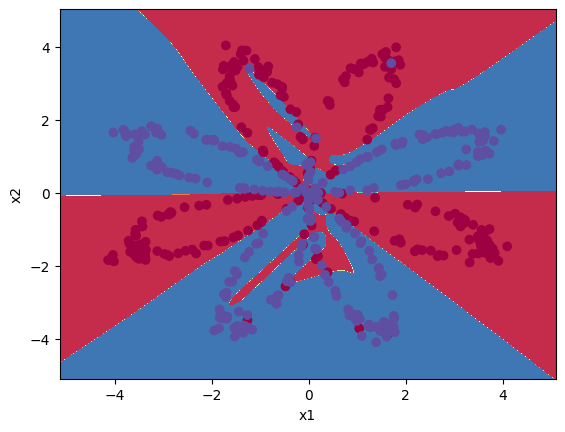

In [58]:
plot_decision_boundary(lambda x:predict(x.T,params),X,Y)